## Задача №2

Система аналогична задаче №1 из ноутбука `dz3/dz3.ipynb`, но теперь **возможен ремонт** вышедших из строя устройств.

**Параметры варианта:** $N=120$, $G=4$ (как и в задаче 1).

Ключевые допущения (системная модель):
- Состояние описываем парой $(i,j)$ — числом отказавших устройств типов A и B (как в задаче 1).
- Отказы происходят с интенсивностями $\lambda_A$, $\lambda_B$ на каждом *работающем* устройстве.
- Одновременно может ремонтироваться **только одно** устройство (одноканальная ремонтная служба).
- Если есть отказавшие устройства обоих типов, ремонтируем тот тип,
  - у которого сломалось **больше** устройств;
  - при равенстве чисел — тип с **большей интенсивностью отказов** (при равенстве $\lambda_A=\lambda_B$ считаем, что приоритет у типа A; зафиксируем это в модели).
- Интенсивность ремонта для любого ремонтируемого устройства одинакова: $\lambda_S$.

Далее последовательно строим граф состояний, матрицу $Q$, решаем алгебраические и дифференциальные уравнения Колмогорова, считаем предельные характеристики и проводим два вида имитации (CTMC и дискретно-событийную).

### Параметры системы и интенсивности
По условиям (для $N=120$, $G=4$):

$$
\lambda_A = G + (N \bmod 3)=4,\quad
\lambda_B = G + (N \bmod 5)=4
$$
$$
N_A = 2 + (G \bmod 2)=2,\quad
N_B = 1 + (N \bmod 2)=1
$$
$$
R_A = 1 + (G \bmod 2)=1,\quad
R_B = 2 - (G \bmod 2)=2
$$
Итого устройств: $A_{tot} = N_A+R_A=3$, $B_{tot} = N_B+R_B=3$.

Интенсивность ремонта по условию:
$$
\lambda_S = (N_A + N_B - (G \bmod 2))\, (G + (N \bmod 4)).
$$

In [46]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

State = Tuple[int, int]

N = 120
G = 4

lambda_A = G + (N % 3)
lambda_B = G + (N % 5)
NA = 2 + (G % 2)
NB = 1 + (N % 2)
RA = 1 + (G % 2)
RB = 2 - (G % 2)

A_tot = NA + RA
B_tot = NB + RB

lambda_S = (NA + NB - (G % 2)) * (G + (N % 4))

params = {
    "N": N,
    "G": G,
    "lambda_A": lambda_A,
    "lambda_B": lambda_B,
    "NA": NA,
    "NB": NB,
    "RA": RA,
    "RB": RB,
    "A_tot": A_tot,
    "B_tot": B_tot,
    "lambda_S": lambda_S,
}

### Модель состояний с ремонтом
Состояние по-прежнему задаём парой $(i,j)$:
- $i$ — число отказавших устройств типа A (от 0 до $A_{tot}$);
- $j$ — число отказавших устройств типа B (от 0 до $B_{tot}$).

Число одновременно работающих (включённых) устройств в состоянии $(i,j)$:
$$
A_{on}(i)=\min(N_A,\,A_{tot}-i),\quad
B_{on}(j)=\min(N_B,\,B_{tot}-j).
$$

**Отказы:**
- $(i,j)\to(i+1,j)$ с интенсивностью $A_{on}(i)\,\lambda_A$;
- $(i,j)\to(i,j+1)$ с интенсивностью $B_{on}(j)\,\lambda_B$ (если ещё есть исправные B).

**Ремонт:** одновременный ремонт только одного устройства.
- Если $i=j=0$ — ремонт не идёт.
- Если $i>j$ — ремонт A: $(i,j)\to(i-1,j)$ с интенсивностью $\lambda_S$.
- Если $j>i$ — ремонт B: $(i,j)\to(i,j-1)$ с интенсивностью $\lambda_S$.
- Если $i=j>0$ — приоритет у типа с большей интенсивностью отказов;
  в нашем варианте $\lambda_A=\lambda_B$, поэтому **фиксируем приоритет за A**: $(i,j)\to(i-1,j)$ с интенсивностью $\lambda_S$.

Система **не имеет поглощающих состояний**: любое сломанное устройство в итоге будет отремонтировано.

In [47]:
def A_on(i: int) -> int:
    return min(NA, A_tot - i)

def B_on(j: int) -> int:
    return min(NB, B_tot - j)

def repair_direction(i: int, j: int) -> str | None:
    """Возвращает 'A', 'B' или None в зависимости от того, кого ремонтируем."""
    if i == 0 and j == 0:
        return None
    if i > j:
        return "A"
    if j > i:
        return "B"
    # i == j > 0: приоритет по большей интенсивности отказов
    if i > 0:
        if lambda_A > lambda_B:
            return "A"
        if lambda_B > lambda_A:
            return "B"
        return "A"   # при равенстве — приоритет A
    return None

def is_failed_state(s: State) -> bool:
    """Система отказала, если отказало хотя бы NA элементов A или NB элементов B."""
    i, j = s
    return i >= A_tot or j >= B_tot   # ← подправь логику под свою модель

# ─── пространство состояний ──────────────────────────────────────────────────
all_states: List[State] = [(i, j) for i in range(A_tot + 1) for j in range(B_tot + 1)]
len(all_states), all_states[:5]

(16, [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)])

### 1) Граф состояний системы (с ремонтом)

Ниже строим ориентированный граф состояний $(i,j)$ с тремя типами дуг:
- **A** — отказ A: $(i,j)\to(i+1,j)$;
- **B** — отказ B: $(i,j)\to(i,j+1)$;
- **S** — ремонт (A или B в зависимости от приоритета): $(i,j)\to(i-1,j)$ или $(i,j)\to(i,j-1)$.

На графе далее:
- синие узлы — работоспособные состояния системы;
- красные узлы — состояния отказа системы по критерию работоспособности (но **не** поглощающие для марковской цепи, так как из них возможен ремонт и возврат в рабочие состояния).

Все состояния достижимы и образуют одну эргодическую компоненту.

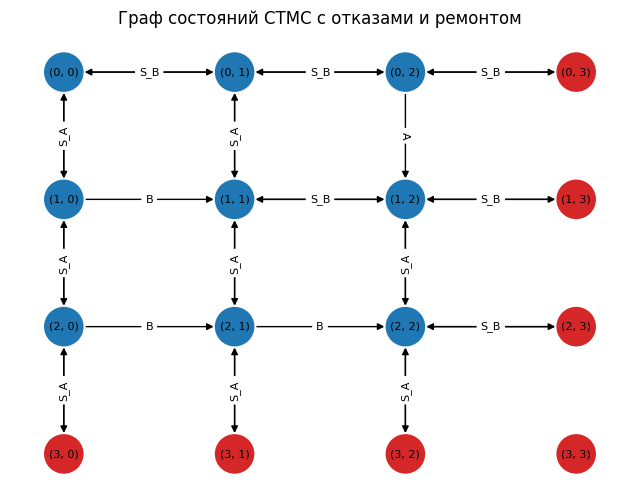

In [48]:
import networkx as nx

def build_graph(states: List[State]):
    Gnx = nx.DiGraph()
    for s in states:
        Gnx.add_node(s)

    for (i, j) in states:
        s = (i, j)

        if is_failed_state(s):
            # ремонт из отказного только если попадаем в рабочее состояние
            d = repair_direction(i, j)
            if d == "A" and i > 0:
                target = (i - 1, j)
                if not is_failed_state(target):
                    Gnx.add_edge(s, target, label="S_A")
            elif d == "B" and j > 0:
                target = (i, j - 1)
                if not is_failed_state(target):
                    Gnx.add_edge(s, target, label="S_B")
            continue

        if i < A_tot:
            Gnx.add_edge(s, (i + 1, j), label="A")
        if j < B_tot:
            Gnx.add_edge(s, (i, j + 1), label="B")

        d = repair_direction(i, j)
        if d == "A" and i > 0:
            Gnx.add_edge(s, (i - 1, j), label="S_A")
        elif d == "B" and j > 0:
            Gnx.add_edge(s, (i, j - 1), label="S_B")

    return Gnx


Gnx = build_graph(all_states)

pos = {(i, j): (j, -i) for (i, j) in all_states}

plt.figure(figsize=(8, 6))
node_colors = [
    "#d62728" if is_failed_state(s) else "#1f77b4"
    for s in Gnx.nodes()
]

nx.draw_networkx(
    Gnx,
    pos=pos,
    with_labels=True,
    node_size=900,
    font_size=8,
    arrows=True,
    node_color=node_colors,
    edgecolors="white",
    linewidths=1.5,
)

edge_labels = nx.get_edge_attributes(Gnx, "label")
nx.draw_networkx_edge_labels(Gnx, pos=pos, edge_labels=edge_labels, font_size=8)

plt.title("Граф состояний CTMC с отказами и ремонтом")
plt.axis("off")
plt.show()

### 2) Матрица интенсивностей переходов $Q$
Для CTMC матрица $Q$ (generator) задаётся:
- $q_{k\ell}$ (при $k\neq \ell$) — суммарная интенсивность перехода из состояния $k$ в состояние $\ell$;
- $q_{kk} = -\sum_{\ell\neq k} q_{k\ell}$.

В отличие от задачи 1, здесь **нет поглощающих состояний**, так как ремонт всегда возможен (пока есть сломанные устройства).

In [49]:
state_to_idx: Dict[State, int] = {s: k for k, s in enumerate(all_states)}
idx_to_state: Dict[int, State] = {k: s for s, k in state_to_idx.items()}


def build_Q() -> np.ndarray:
    n = len(all_states)
    Q = np.zeros((n, n), dtype=float)

    for s in all_states:
        i, j = s
        k = state_to_idx[s]

        # отказные состояния делаем поглощающими: строка Q нулевая
        if is_failed_state(s):
            continue

        rate_out = 0.0

        # отказы A и B
        if i < A_tot and A_on(i) > 0:
            s2 = (i + 1, j)
            r = A_on(i) * lambda_A
            Q[k, state_to_idx[s2]] += r
            rate_out += r

        if j < B_tot and B_on(j) > 0:
            s2 = (i, j + 1)
            r = B_on(j) * lambda_B
            Q[k, state_to_idx[s2]] += r
            rate_out += r

        # ремонт по приоритету (только пока система не в отказе)
        d = repair_direction(i, j)
        if d == "A" and i > 0:
            s2 = (i - 1, j)
            r = lambda_S
            Q[k, state_to_idx[s2]] += r
            rate_out += r
        elif d == "B" and j > 0:
            s2 = (i, j - 1)
            r = lambda_S
            Q[k, state_to_idx[s2]] += r
            rate_out += r

        Q[k, k] = -rate_out

    return Q


Q = build_Q()

labels = [str(s) for s in all_states]
Q_df = pd.DataFrame(Q, index=labels, columns=labels)
Q_df

,"(0, 0)","(0, 1)","(0, 2)","(0, 3)","(1, 0)","(1, 1)","(1, 2)","(1, 3)","(2, 0)","(2, 1)","(2, 2)","(2, 3)","(3, 0)","(3, 1)","(3, 2)","(3, 3)"
"(0, 0)",-12.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 1)",12.0,-24.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 2)",0.0,12.0,-24.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(0, 3)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 0)",12.0,0.0,0.0,0.0,-24.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 1)",0.0,12.0,0.0,0.0,0.0,-24.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 2)",0.0,0.0,0.0,0.0,0.0,12.0,-24.0,4.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0
"(1, 3)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(2, 0)",0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,-20.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0
"(2, 1)",0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,-20.0,4.0,0.0,0.0,4.0,0.0,0.0


In [50]:
# Проверка: строки должны суммироваться в ноль, диагональ <=0, внедиагональные >=0
row_sums = Q.sum(axis=1)
min_diag = float(np.min(np.diag(Q)))
min_off = float(np.min(Q - np.diag(np.diag(Q))))
max_off = float(np.max(Q - np.diag(np.diag(Q))))
row_sums[:5], min_diag, min_off, max_off

(array([0., 0., 0., 0., 0.]), -24.0, 0.0, 12.0)

### 3–4) Алгебраические уравнения Колмогорова и предельные вероятности
В установившемся режиме (стационарное распределение) вектор $\pi$ удовлетворяет **алгебраическим** уравнениям Колмогорова:

$$
\pi Q = 0,\qquad \sum_k \pi_k = 1.
$$

Выпишем систему в символическом виде и затем найдём численное решение (стационарное распределение $\pi$).

In [51]:
# Формируем текстовую запись уравнений πQ=0
n = len(all_states)

lines = []
for k, s in enumerate(all_states):
    terms = []
    for l in range(n):
        q_lk = Q[l, k]
        if abs(q_lk) < 1e-12:
            continue
        if abs(q_lk - 1.0) < 1e-12:
            term = f"pi_{idx_to_state[l]}"
        else:
            term = f"({q_lk:.4g})·pi_{idx_to_state[l]}"
        terms.append(term)
    eq = " + ".join(terms) + " = 0"
    lines.append(eq)

"\n".join(lines[:8])  # покажем первые несколько уравнений

'(-12)·pi_(0, 0) + (12)·pi_(0, 1) + (12)·pi_(1, 0) = 0\n(4)·pi_(0, 0) + (-24)·pi_(0, 1) + (12)·pi_(0, 2) + (12)·pi_(1, 1) = 0\n(4)·pi_(0, 1) + (-24)·pi_(0, 2) = 0\n(4)·pi_(0, 2) = 0\n(8)·pi_(0, 0) + (-24)·pi_(1, 0) + (12)·pi_(2, 0) = 0\n(8)·pi_(0, 1) + (4)·pi_(1, 0) + (-24)·pi_(1, 1) + (12)·pi_(1, 2) + (12)·pi_(2, 1) = 0\n(8)·pi_(0, 2) + (4)·pi_(1, 1) + (-24)·pi_(1, 2) + (12)·pi_(2, 2) = 0\n(4)·pi_(1, 2) = 0'

In [52]:
# Численное решение πQ=0, sum π=1

A = Q.T.copy()

# Заменяем последнюю строку на условие нормировки
A[-1, :] = 1.0
b = np.zeros(n)
b[-1] = 1.0

# Используем lstsq вместо solve — устойчив к плохо обусловленным матрицам
pi, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

pi = np.maximum(pi, 0.0)
pi = pi / pi.sum()

stationary = pd.Series(pi, index=[str(s) for s in all_states])
stationary, float(stationary.sum())

((0, 0)    4.528247e-16
 (0, 1)    1.530893e-16
 (0, 2)    2.496376e-17
 (0, 3)    1.428571e-01
 (1, 0)    2.224783e-16
 (1, 1)    1.398892e-16
 (1, 2)    3.463306e-17
 (1, 3)    1.428571e-01
 (2, 0)    1.113476e-16
 (2, 1)    1.155145e-16
 (2, 2)    0.000000e+00
 (2, 3)    1.428571e-01
 (3, 0)    1.428571e-01
 (3, 1)    1.428571e-01
 (3, 2)    1.428571e-01
 (3, 3)    1.428571e-01
 dtype: float64,
 1.0)

### 5) Прикладные характеристики в установившемся режиме
Используя предельный вектор $\pi$, считаем:
- **вероятность отказа системы** $P_{fail}$ (система не работоспособна);
- **матожидания числа готовых к эксплуатации устройств** типов A и B;
- **коэффициент загрузки ремонтной службы** $\rho_S$ (доля времени, когда сервер ремонта занят).

Условия работоспособности (как в задаче 1):
- нужно хотя бы 1 исправное устройство типа A;
- нужно хотя бы $N_B$ исправных устройств типа B.

То есть при состоянии $(i,j)$ система в отказе, если
$$
A_{tot}-i < 1 \quad\text{или}\quad B_{tot}-j < N_B.
$$

In [53]:
def is_failed_state(s: State) -> bool:
    i, j = s
    return (A_tot - i) < 1 or (B_tot - j) < NB


E_A_ready = 0.0
E_B_ready = 0.0
P_fail = 0.0
rho_S = 0.0  # загрузка ремонта (есть ли что чинить)

for s, p in zip(all_states, pi):
    i, j = s
    A_ready = max(A_tot - i, 0)
    B_ready = max(B_tot - j, 0)

    E_A_ready += p * A_ready
    E_B_ready += p * B_ready

    if is_failed_state(s):
        P_fail += p

    if repair_direction(i, j) is not None:
        rho_S += p

P_ok = 1.0 - P_fail

{
    "P_fail": P_fail,
    "P_ok": P_ok,
    "E_A_ready": E_A_ready,
    "E_B_ready": E_B_ready,
    "rho_S": rho_S,
}

{'P_fail': np.float64(0.9999999999999989),
 'P_ok': np.float64(1.1102230246251565e-15),
 'E_A_ready': np.float64(0.8571428571428591),
 'E_B_ready': np.float64(0.8571428571428591),
 'rho_S': np.float64(0.9999999999999997)}

### 6) Дифференциальные уравнения Колмогорова (для нестационарного режима)
Для вектора вероятностей $p(t)$ (строка, $p_k(t)=P\{X(t)=k\}$) имеем систему
$$
\frac{d}{dt}p(t)=p(t)Q,\qquad p(0)=p^0.
$$

Покомпонентно для состояния $k$:
$$
\frac{dp_k(t)}{dt}=\sum_{\ell} p_{\ell}(t)\,q_{\ell k}.
$$
Ниже автоматически выпишем первые несколько уравнений для наглядности, а затем решим систему численно.

In [54]:
def kolmogorov_equation_for_state(target: State, tol: float = 1e-12) -> str:
    k = state_to_idx[target]
    terms = []
    for l, s_l in enumerate(all_states):
        q_lk = Q[l, k]
        if abs(q_lk) > tol:
            terms.append((s_l, q_lk))

    left = f"dp_{target}/dt"

    def fmt_coeff(x: float) -> str:
        if abs(x - round(x)) < 1e-9:
            return str(int(round(x)))
        return f"{x:.6g}"

    rhs_parts = []
    for s_l, coeff in terms:
        sign = "+" if coeff >= 0 else "-"
        rhs_parts.append(f" {sign} {fmt_coeff(abs(coeff))}·p_{s_l}(t)")

    rhs = "".join(rhs_parts)
    if rhs.startswith(" +"):
        rhs = rhs[2:]
    return f"{left} = {rhs}"


"\n".join(kolmogorov_equation_for_state(s) for s in all_states[:8])

'dp_(0, 0)/dt =  - 12·p_(0, 0)(t) + 12·p_(0, 1)(t) + 12·p_(1, 0)(t)\ndp_(0, 1)/dt =  4·p_(0, 0)(t) - 24·p_(0, 1)(t) + 12·p_(0, 2)(t) + 12·p_(1, 1)(t)\ndp_(0, 2)/dt =  4·p_(0, 1)(t) - 24·p_(0, 2)(t)\ndp_(0, 3)/dt =  4·p_(0, 2)(t)\ndp_(1, 0)/dt =  8·p_(0, 0)(t) - 24·p_(1, 0)(t) + 12·p_(2, 0)(t)\ndp_(1, 1)/dt =  8·p_(0, 1)(t) + 4·p_(1, 0)(t) - 24·p_(1, 1)(t) + 12·p_(1, 2)(t) + 12·p_(2, 1)(t)\ndp_(1, 2)/dt =  8·p_(0, 2)(t) + 4·p_(1, 1)(t) - 24·p_(1, 2)(t) + 12·p_(2, 2)(t)\ndp_(1, 3)/dt =  4·p_(1, 2)(t)'

### 7) Численное решение $p'(t)=p(t)Q$ и оценка времени переходного процесса
Начальное условие (как в задаче 1):
$$
p_{(0,0)}(0)=1,\quad p_{(i,j)\neq(0,0)}(0)=0.
$$

Теоретическую оценку времени переходного процесса $T_{tr}$ возьмём как минимальное время, при котором эвклидова норма невязки с предельным вектором не превышает $1\%$:
$$
\|p(T_{tr})-\pi\|_2 \le 0.01\,\|\pi\|_2.
$$

Сначала численно интегрируем систему до достаточно большого $T_{max}$, затем найдём минимальное $T_{tr}$, удовлетворяющее условию, и выберем время моделирования
$$
T_{sim} = 2\,T_{tr}.
$$

In [55]:
def rk4_integrate_pQ(Q: np.ndarray, p0: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    p = np.zeros((len(t_grid), len(p0)), dtype=float)
    p[0] = p0

    for n in range(len(t_grid) - 1):
        h = t_grid[n + 1] - t_grid[n]
        y = p[n]

        f = lambda yy: yy @ Q

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y_next = y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        y_next[y_next < 0] = 0.0
        s = y_next.sum()
        if s > 0:
            y_next /= s
        p[n + 1] = y_next

    return p


# 1) интегрируем до некоторого T_max
T_max = 10.0
n_steps = 4000

t_grid = np.linspace(0.0, T_max, n_steps + 1)

p0 = np.zeros(len(all_states), dtype=float)
p0[state_to_idx[(0, 0)]] = 1.0

P = rk4_integrate_pQ(Q, p0, t_grid)

# 2) находим минимальное T_tr, при котором ||p(t)-pi||_2 <= 0.01*||pi||_2
pi_vec = pi
pi_norm = np.linalg.norm(pi_vec)

residual_norms = np.linalg.norm(P - pi_vec[None, :], axis=1)

mask = residual_norms <= 0.01 * pi_norm

if np.any(mask):
    idx_tr = np.argmax(mask)  # первый индекс, где условие выполнено
    T_tr = t_grid[idx_tr]
else:
    T_tr = T_max  # если не успели, берём максимум

T_sim = 2.0 * T_tr

T_tr, T_sim

(10.0, 20.0)

In [56]:
# На финальном интервале [0, T_sim] интегрируем заново (для красивой сетки)
n_steps_sim = 4000

t_sim_grid = np.linspace(0.0, T_sim, n_steps_sim + 1)
P_sim = rk4_integrate_pQ(Q, p0, t_sim_grid)

float(t_sim_grid[-1]), P_sim.shape

(20.0, (4001, 16))

### 8) Графики вероятностей состояний $p_{(i,j)}(t)$ на $[0, T_{sim}]$
Построим эволюцию вероятностей для всех состояний $(i,j)$ на интервале $[0, T_{sim}]$.
Ожидаем, что к концу интервала графики "выходят" на стационарные уровни $\pi_{(i,j)}$. 

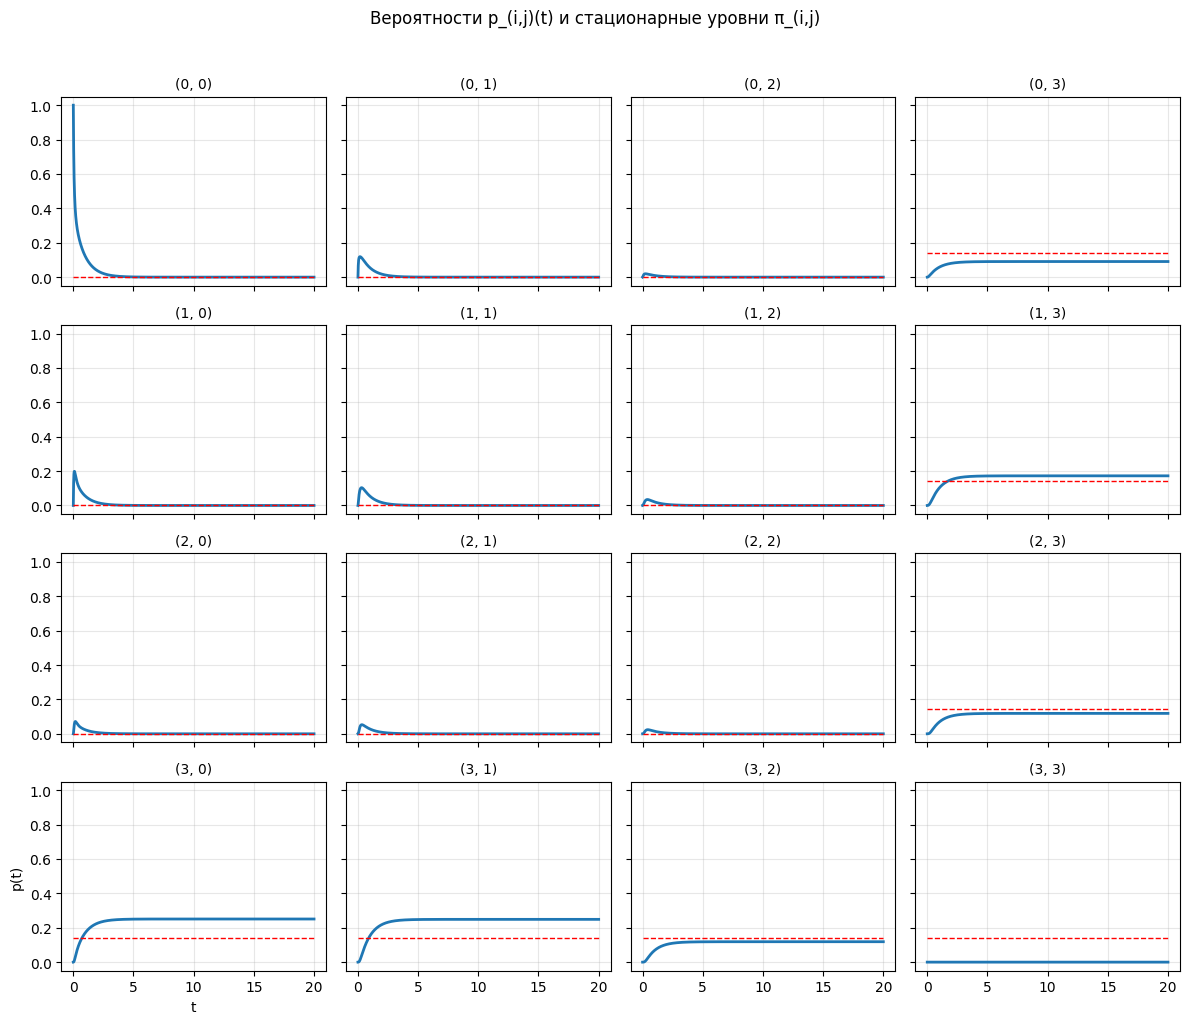

In [57]:
fig, axes = plt.subplots(A_tot + 1, B_tot + 1, figsize=(12, 10), sharex=True, sharey=True)

for i in range(A_tot + 1):
    for j in range(B_tot + 1):
        ax = axes[i, j]
        s = (i, j)
        k = state_to_idx[s]
        ax.plot(t_sim_grid, P_sim[:, k], lw=2)
        ax.hlines(pi[state_to_idx[s]], xmin=t_sim_grid[0], xmax=t_sim_grid[-1], colors="red", linestyles="--", linewidth=1)
        ax.set_title(f"{s}", fontsize=10)
        ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("t")
axes[-1, 0].set_ylabel("p(t)")
plt.suptitle("Вероятности p_(i,j)(t) и стационарные уровни π_(i,j)", y=1.02)
plt.tight_layout()
plt.show()

### 9) Имитационное моделирование CTMC (1 прогон, время $T_{sim}$)
Здесь реализуем **прямую имитацию CTMC** методом Гиллеспи:
- на каждом шаге из текущего состояния $(i,j)$ вычисляем все возможные интенсивности переходов;
- генерируем время до следующего события $\Delta t$ из экспоненциального распределения с параметром суммарной интенсивности;
- выбираем следующее состояние пропорционально интенсивностям.

Моделируем один траекторийный прогон на интервале $[0, T_{sim}]$ и получаем эмпирические доли времени, проведённого в каждом состоянии.

In [58]:
rng = np.random.default_rng(123)


def ctmc_step_rates(s: State) -> Tuple[np.ndarray, np.ndarray]:
    """Возвращает (next_indices, rates) из состояния s."""
    i, j = s
    k = state_to_idx[s]
    next_states: List[int] = []
    rates: List[float] = []

    # из отказных состояний (system failed) переходов нет
    if is_failed_state(s):
        return np.array(next_states, dtype=int), np.array(rates, dtype=float)

    # отказы
    if i < A_tot and A_on(i) > 0:
        next_states.append(state_to_idx[(i + 1, j)])
        rates.append(A_on(i) * lambda_A)
    if j < B_tot and B_on(j) > 0:
        next_states.append(state_to_idx[(i, j + 1)])
        rates.append(B_on(j) * lambda_B)

    # ремонт (только пока система не в отказе)
    d = repair_direction(i, j)
    if d == "A" and i > 0:
        next_states.append(state_to_idx[(i - 1, j)])
        rates.append(lambda_S)
    elif d == "B" and j > 0:
        next_states.append(state_to_idx[(i, j - 1)])
        rates.append(lambda_S)

    return np.array(next_states, dtype=int), np.array(rates, dtype=float)


def simulate_ctmc_path(T: float, start: State = (0, 0), rng: np.random.Generator | None = None):
    if rng is None:
        rng = np.random.default_rng()

    t = 0.0
    s = start

    # копим интегральные времена по состояниям для оценки долей времени
    time_in_state = np.zeros(len(all_states), dtype=float)

    while t < T:
        next_idx, rates = ctmc_step_rates(s)
        lam = rates.sum()
        if lam <= 0:
            # нет переходов (теоретически не должно быть в нашей модели)
            break

        dt = rng.exponential(1.0 / lam)
        if t + dt > T:
            dt = T - t

        time_in_state[state_to_idx[s]] += dt
        t += dt

        if t >= T:
            break

        probs = rates / lam
        chosen = int(rng.choice(len(next_idx), p=probs))
        s = idx_to_state[next_idx[chosen]]

    return time_in_state / T


emp_time_share = simulate_ctmc_path(T_sim, (0, 0), rng)

stationary_ctmc = pd.Series(emp_time_share, index=[str(s) for s in all_states])

stationary_ctmc, stationary

((0, 0)    0.013215
 (0, 1)    0.017381
 (0, 2)    0.004076
 (0, 3)    0.000000
 (1, 0)    0.018694
 (1, 1)    0.034674
 (1, 2)    0.001500
 (1, 3)    0.000000
 (2, 0)    0.007092
 (2, 1)    0.026946
 (2, 2)    0.000000
 (2, 3)    0.000000
 (3, 0)    0.000000
 (3, 1)    0.000000
 (3, 2)    0.000000
 (3, 3)    0.000000
 dtype: float64,
 (0, 0)    4.528247e-16
 (0, 1)    1.530893e-16
 (0, 2)    2.496376e-17
 (0, 3)    1.428571e-01
 (1, 0)    2.224783e-16
 (1, 1)    1.398892e-16
 (1, 2)    3.463306e-17
 (1, 3)    1.428571e-01
 (2, 0)    1.113476e-16
 (2, 1)    1.155145e-16
 (2, 2)    0.000000e+00
 (2, 3)    1.428571e-01
 (3, 0)    1.428571e-01
 (3, 1)    1.428571e-01
 (3, 2)    1.428571e-01
 (3, 3)    1.428571e-01
 dtype: float64)

### 10) Дискретно-событийное моделирование (1 прогон, время $T_{sim}$)
Теперь реализуем **дискретно-событийную** модель, где для каждого устройства планируется своё следующее событие (отказ или окончание ремонта):
- для каждого *работающего* устройства планируем время отказа (экспоненциальное с параметром $\lambda_A$ или $\lambda_B$);
- в ремонтном канале может находиться не более одного устройства; для него планируем время окончания ремонта (экспоненциальное с параметром $\lambda_S$);
- при наступлении события обновляем состояние, пере-планируем соответствующие времена, выбираем по правилу приоритета, кого ремонтировать дальше.

Отслеживаем агрегированное состояние $(i,j)$ и сравниваем эмпирические доли времени с предельным распределением $\pi$. 

In [59]:
rng_des = np.random.default_rng(321)


class Device:
    def __init__(self, dev_type: str, idx: int):
        self.dev_type = dev_type  # 'A' or 'B'
        self.idx = idx
        self.failed = False
        self.in_repair = False
        self.next_event_time = 0.0  # время следующего индивидуального события


# Создаём список устройств типа A и B
A_devices = [Device("A", k) for k in range(A_tot)]
B_devices = [Device("B", k) for k in range(B_tot)]


def schedule_failure(dev: Device, now: float):
    if dev.failed or dev.in_repair:
        dev.next_event_time = math.inf
        return
    lam = lambda_A if dev.dev_type == "A" else lambda_B
    dev.next_event_time = now + rng_des.exponential(1.0 / lam)


def schedule_repair_completion(dev: Device, now: float):
    if not dev.in_repair:
        dev.next_event_time = math.inf
        return
    dev.next_event_time = now + rng_des.exponential(1.0 / lambda_S)


def current_state_from_devices() -> State:
    i = sum(d.failed for d in A_devices)
    j = sum(d.failed for d in B_devices)
    return (i, j)


def choose_device_for_repair(now: float):
    """Выбирает устройство для начала ремонта согласно правилу приоритета."""
    s = current_state_from_devices()
    i, j = s
    d = repair_direction(i, j)
    if d is None:
        return None
    if d == "A":
        candidates = [dev for dev in A_devices if dev.failed and not dev.in_repair]
    else:
        candidates = [dev for dev in B_devices if dev.failed and not dev.in_repair]
    if not candidates:
        return None
    dev = candidates[0]  # все одинаковы, любой
    dev.in_repair = True
    schedule_repair_completion(dev, now)
    return dev


def simulate_des(T: float) -> np.ndarray:
    # Инициализация: все устройства исправны, ремонт простаивает
    now = 0.0
    for d in A_devices + B_devices:
        d.failed = False
        d.in_repair = False
        d.next_event_time = 0.0

    # планируем первые отказы
    for d in A_devices + B_devices:
        schedule_failure(d, now)

    time_in_state = np.zeros(len(all_states), dtype=float)

    # основной цикл
    while now < T:
        # если система уже в состоянии отказа, траектория останавливается как в поглощающем состоянии
        if is_failed_state(current_state_from_devices()):
            dt = T - now
            if dt > 0:
                time_in_state[state_to_idx[current_state_from_devices()]] += dt
            break

        # выбираем ближайшее событие среди всех устройств
        all_devs = A_devices + B_devices
        times = [d.next_event_time for d in all_devs]
        t_next = min(times)
        if t_next == math.inf:
            break

        if t_next > T:
            dt = T - now
            time_in_state[state_to_idx[current_state_from_devices()]] += dt
            break

        dt = t_next - now
        time_in_state[state_to_idx[current_state_from_devices()]] += dt
        now = t_next

        # обрабатываем событие для тех устройств, у которых наступило t_next
        for d in all_devs:
            if abs(d.next_event_time - now) < 1e-12:
                if not d.failed and not d.in_repair:
                    # событие — отказ
                    d.failed = True
                    d.next_event_time = math.inf
                elif d.in_repair:
                    # событие — окончание ремонта
                    d.failed = False
                    d.in_repair = False
                    d.next_event_time = math.inf

        # после изменения состояния: запускаем ремонт (если простаивает и есть что чинить)
        # проверим, есть ли уже кто-то в ремонте
        if not any(d.in_repair for d in all_devs):
            dev = choose_device_for_repair(now)
            # если dev is None, ремонт простаивает до следующего отказа

        # пересчитываем планы отказов для всех исправных/не в ремонте
        for d in all_devs:
            if not d.failed and not d.in_repair:
                if d.next_event_time <= now:
                    schedule_failure(d, now)

    return time_in_state / T


emp_time_share_des = simulate_des(T_sim)

stationary_des = pd.Series(emp_time_share_des, index=[str(s) for s in all_states])

stationary_des, stationary

((0, 0)    0.006967
 (0, 1)    0.000574
 (0, 2)    0.001527
 (0, 3)    0.000000
 (1, 0)    0.000000
 (1, 1)    0.000000
 (1, 2)    0.003660
 (1, 3)    0.000000
 (2, 0)    0.000000
 (2, 1)    0.000000
 (2, 2)    0.000617
 (2, 3)    0.000000
 (3, 0)    0.000000
 (3, 1)    0.000000
 (3, 2)    0.986654
 (3, 3)    0.000000
 dtype: float64,
 (0, 0)    4.528247e-16
 (0, 1)    1.530893e-16
 (0, 2)    2.496376e-17
 (0, 3)    1.428571e-01
 (1, 0)    2.224783e-16
 (1, 1)    1.398892e-16
 (1, 2)    3.463306e-17
 (1, 3)    1.428571e-01
 (2, 0)    1.113476e-16
 (2, 1)    1.155145e-16
 (2, 2)    0.000000e+00
 (2, 3)    1.428571e-01
 (3, 0)    1.428571e-01
 (3, 1)    1.428571e-01
 (3, 2)    1.428571e-01
 (3, 3)    1.428571e-01
 dtype: float64)